# Data Handling

#### Importing all the libraries required for data handling, visualization, preprocessing, classification models, evaluation and hyperparameter tuning and saving the trained models.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score, accuracy_score,roc_auc_score,pairwise_distances,log_loss)
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, plot_importance, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import joblib as joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline




#### Loading the UCI Obesity Levels dataset directly from the UCI repository, The SSL setting is changed to allow the dataset to be downloaded despite the certificate issue.

In [3]:

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

data = pd.read_csv("https://archive.ics.uci.edu/static/public/544/data.csv")

#### Initial look at the features and target variable. 

In [4]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


#### Look for any missing values as it could affect the model. 

In [5]:
data.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

#### Checking the number of rows and columns, the data type of each feature and the target variable and look for any missing values

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [7]:
print(data['NObeyesdad'].dtype)

str


#### The features are separated into categorical and numerical columns. It is necessary to separate them because they have different preprocessing methods.

In [8]:
catCol = data.drop('NObeyesdad',axis=1).select_dtypes(include=["str"]).columns
numCol = data.select_dtypes(include=["float64"]).columns

print("Categorical columns: ", catCol)

print("Numerical columns: ", numCol)

Categorical columns:  Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS'],
      dtype='str')
Numerical columns:  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='str')


#### The obesity categories are mapped to numerical values so that the relationship between the obesity level and the numerical features can be visualised.

In [9]:
data['NObeyesdad_num'] = data['NObeyesdad'].map({
    'Insufficient_Weight': -1,
    'Normal_Weight': 0,
    'Overweight_Level_I': 1,
    'Overweight_Level_II': 2,
    'Obesity_Type_I': 3,
    'Obesity_Type_II':4,
    'Obesity_Type_III': 5
})

#### Body Mass Index (BMI) is added as an additional feature because it is directly related to weight classification.

In [11]:
data['BMI'] = data['Weight']/(data['Height']**2)
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,NObeyesdad_num,BMI
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,0,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,0,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,0,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,1,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,2,28.342381


#### Some of the survey variables contain decimal values even though they represent discrete response scales. These values are rounded so that they better match the original survey categories.

In [12]:
print(data['FCVC'].value_counts())
print(data['NCP'].value_counts())
print(data['CH2O'].value_counts())
print(data['FAF'].value_counts())
print(data['TUE'].value_counts())

FCVC
3.000000    652
2.000000    600
1.000000     33
2.392665      2
2.714447      2
           ... 
2.919526      1
2.724121      1
2.801992      1
2.748971      1
2.680375      1
Name: count, Length: 810, dtype: int64
NCP
3.000000    1203
1.000000     199
4.000000      69
1.737620       2
1.894384       2
            ... 
2.142328       1
1.437959       1
1.343117       1
1.213431       1
1.089048       1
Name: count, Length: 635, dtype: int64
CH2O
2.000000    448
1.000000    211
3.000000    162
2.825629      3
1.636326      3
           ... 
1.728139      1
2.005130      1
2.054193      1
2.852339      1
2.863513      1
Name: count, Length: 1268, dtype: int64
FAF
0.000000    411
1.000000    234
2.000000    183
3.000000     75
1.541072      2
           ... 
1.676269      1
1.341390      1
1.414209      1
1.139107      1
1.026452      1
Name: count, Length: 1190, dtype: int64
TUE
0.000000    557
1.000000    292
2.000000    109
0.630866      4
1.119877      3
           ... 
0.906247 

In [13]:

data['FCVC']= data['FCVC'].map(lambda num : round(num))
data['NCP']= data['NCP'].map(lambda num : round(num))
data['CH2O']= data['CH2O'].map(lambda num : round(num))
data['FAF']= data['FAF'].map(lambda num : round(num))
data['TUE']= data['TUE'].map(lambda num : round(num))

print(data['FCVC'].value_counts())
print(data['NCP'].value_counts())
print(data['CH2O'].value_counts())
print(data['FAF'].value_counts())
print(data['TUE'].value_counts())

FCVC
2    1013
3     996
1     102
Name: count, dtype: int64
NCP
3    1470
1     316
2     176
4     149
Name: count, dtype: int64
CH2O
2    1110
3     516
1     485
Name: count, dtype: int64
FAF
1    776
0    720
2    496
3    119
Name: count, dtype: int64
TUE
0    952
1    915
2    244
Name: count, dtype: int64


#### These scatter plots are used to explore how each numerical feature changes across the different obesity levels. This helps identify possible relationships or patterns in the data.

<Figure size 1000x600 with 0 Axes>

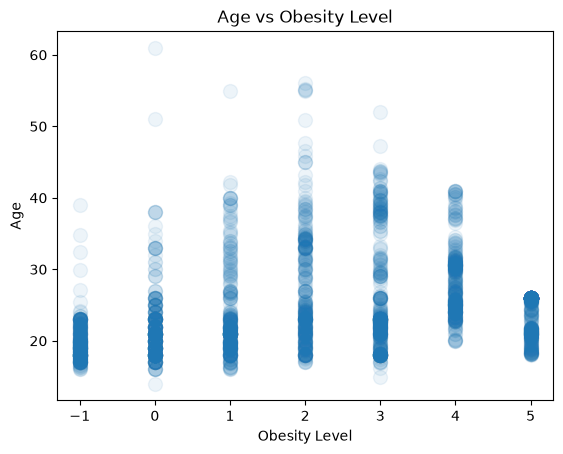

<Figure size 1000x600 with 0 Axes>

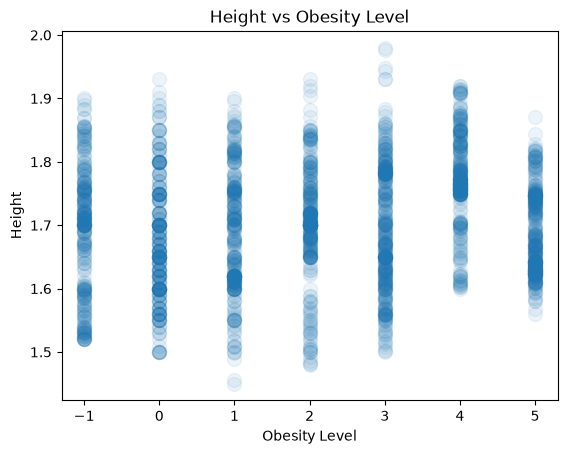

<Figure size 1000x600 with 0 Axes>

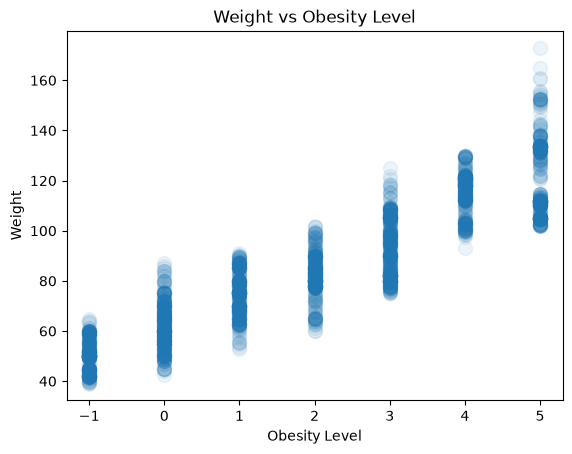

<Figure size 1000x600 with 0 Axes>

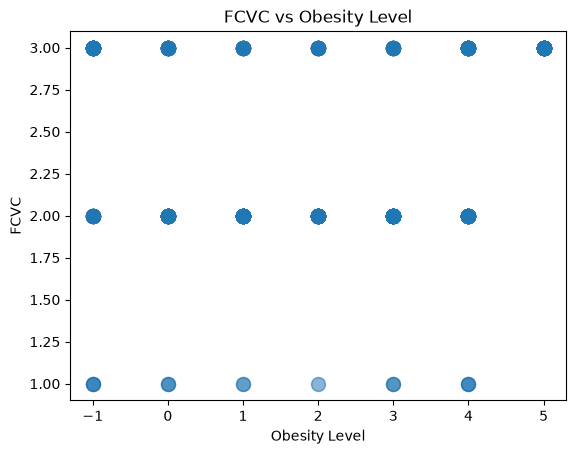

<Figure size 1000x600 with 0 Axes>

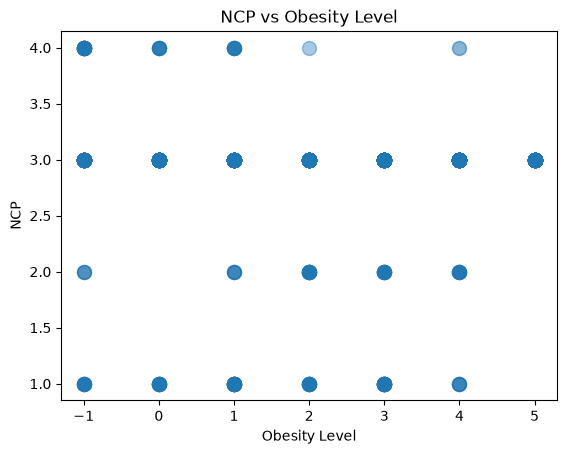

<Figure size 1000x600 with 0 Axes>

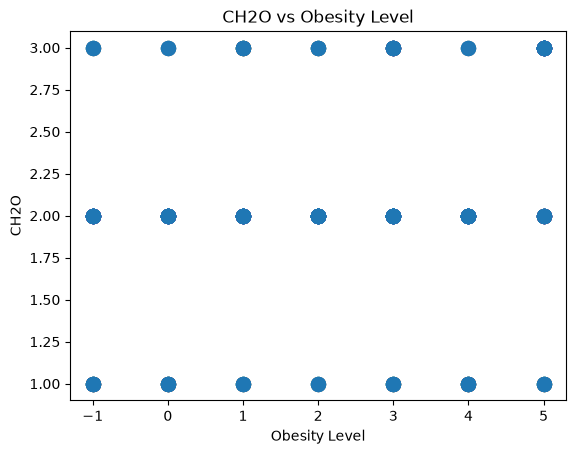

<Figure size 1000x600 with 0 Axes>

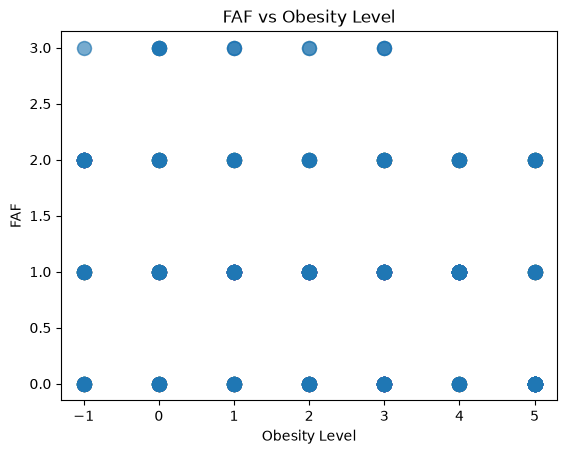

<Figure size 1000x600 with 0 Axes>

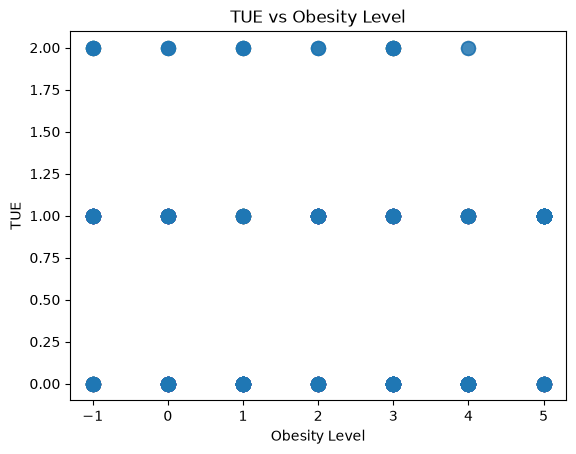

In [14]:
for col in numCol:
    plt.figure(figsize=(10, 6))
    
    data.plot(
        kind='scatter',
        x='NObeyesdad_num',
        y=col,
        s=100,
        alpha=0.08
    )
    
    plt.xlabel('Obesity Level')
    plt.ylabel(col)
    plt.title(f'{col} vs Obesity Level')
    plt.show()

#### Box plots are created for the numerical features to compare their distributions across the different obesity levels and identify possible differences or outliers.

<Figure size 1000x600 with 0 Axes>

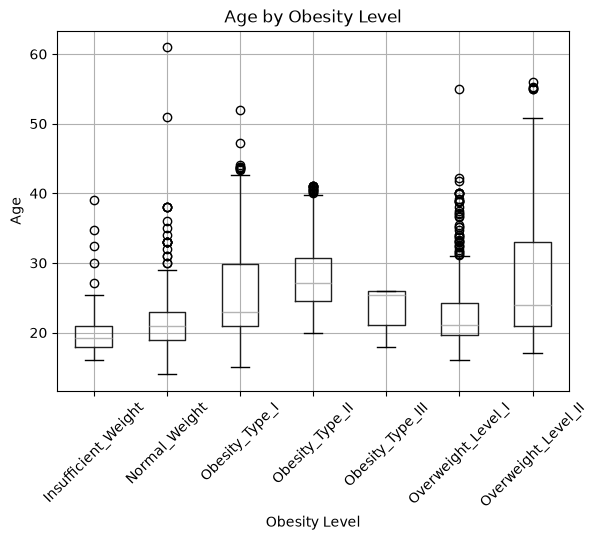

<Figure size 1000x600 with 0 Axes>

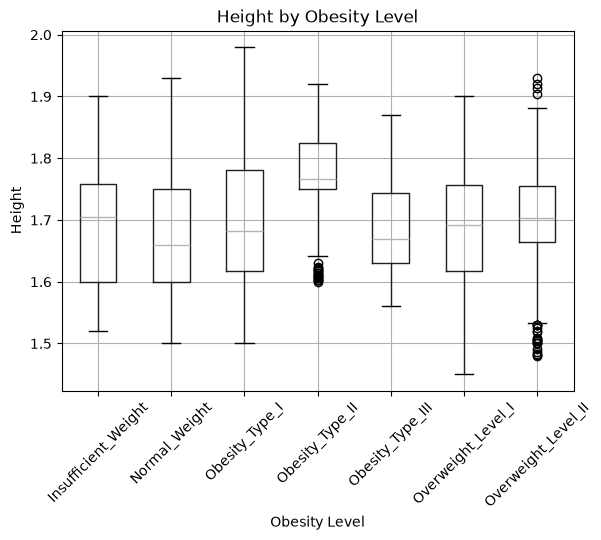

<Figure size 1000x600 with 0 Axes>

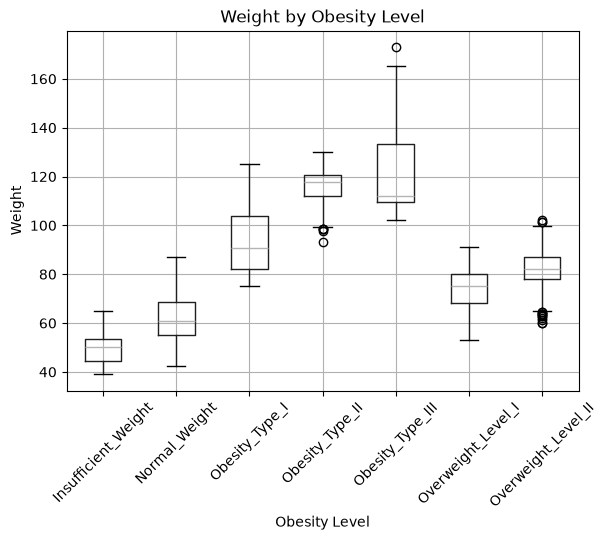

<Figure size 1000x600 with 0 Axes>

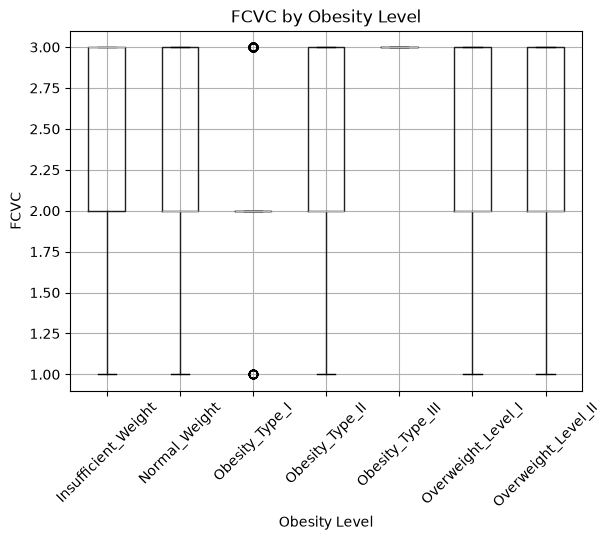

<Figure size 1000x600 with 0 Axes>

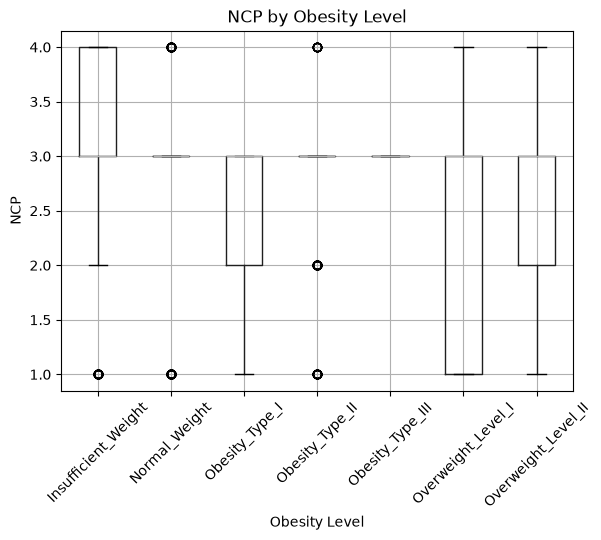

<Figure size 1000x600 with 0 Axes>

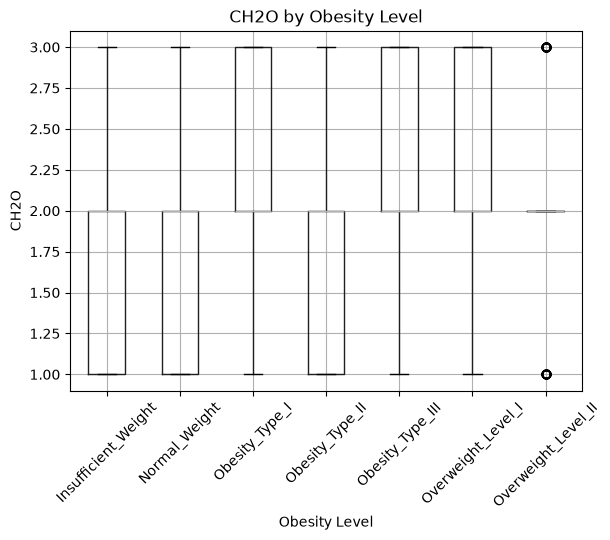

<Figure size 1000x600 with 0 Axes>

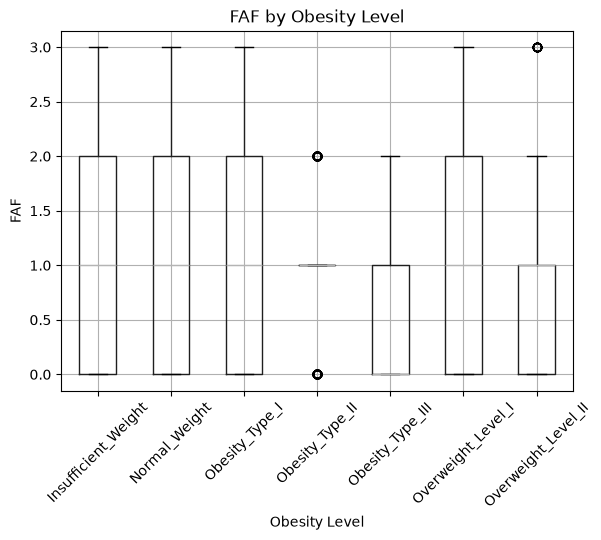

<Figure size 1000x600 with 0 Axes>

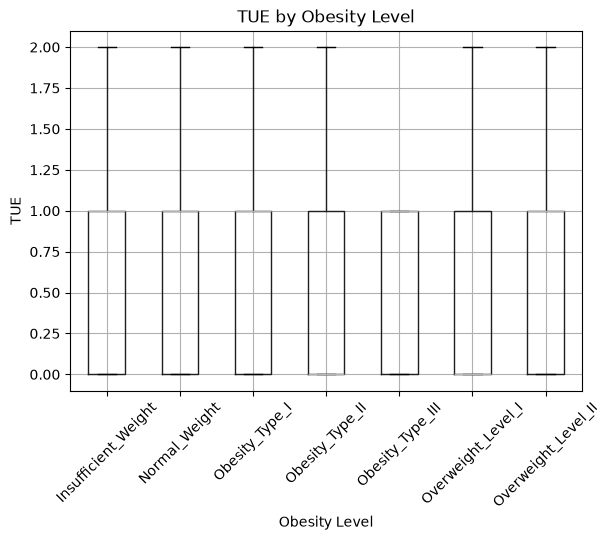

In [15]:
for col in numCol:
    plt.figure(figsize=(10, 6))
    
    data.boxplot(column=col, by='NObeyesdad')
    
    plt.title(f'{col} by Obesity Level')
    plt.suptitle('')
    plt.xlabel('Obesity Level')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    
    plt.show()

#### Count plots are used to compare the categorical features across the different obesity levels. This helps identify whether certain categories appear more frequently within particular target classes.

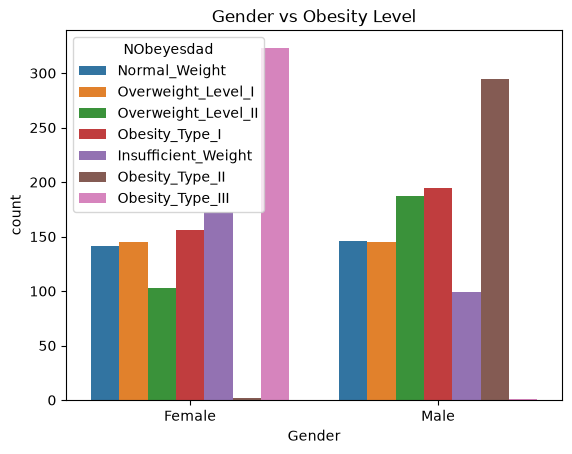

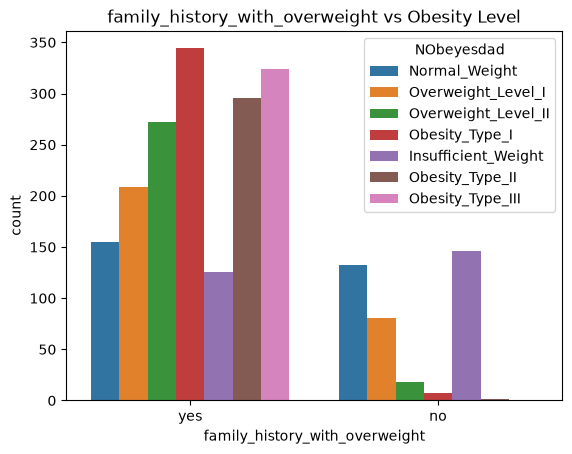

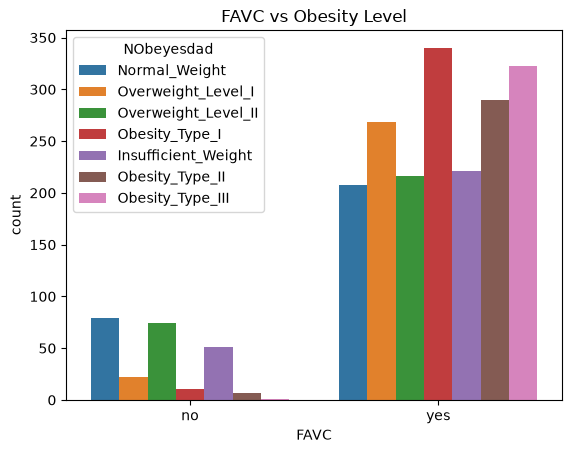

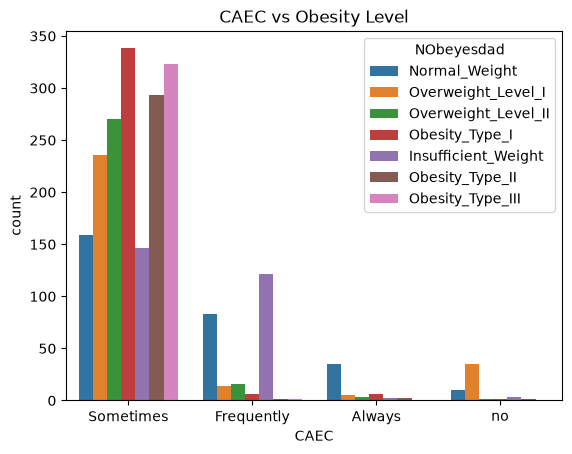

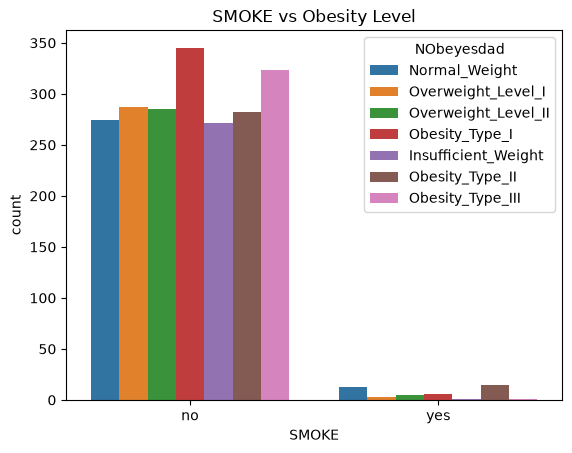

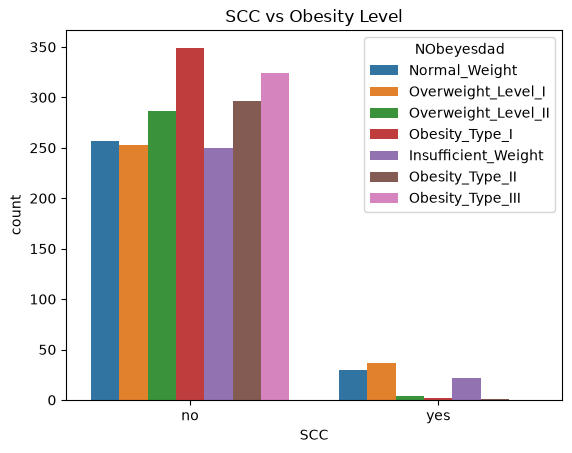

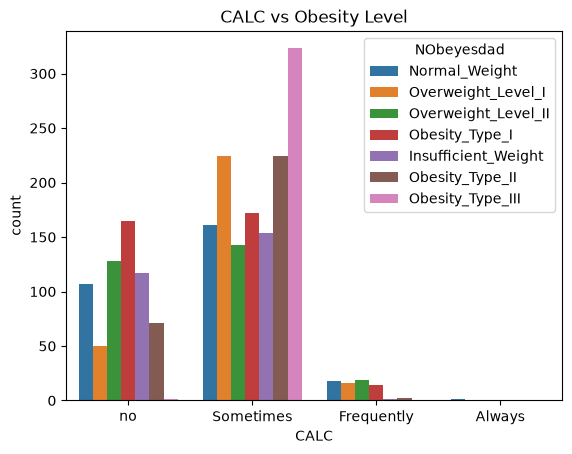

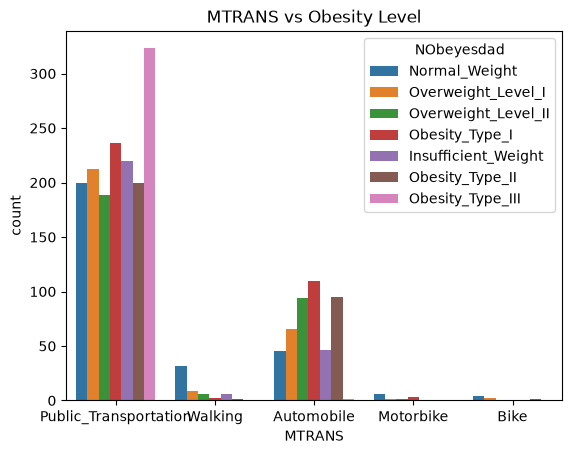

In [16]:
for col in catCol:
        # 'feature' on x-axis, 'target' represented by color (hue)
    sns.countplot(data=data, x=col, hue='NObeyesdad')
    plt.title(col + " vs Obesity Level")
    plt.show()

In [17]:
X = data.drop(['NObeyesdad', 'NObeyesdad_num'], axis=1)
y = data['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Checking how many observations belong to each obesity class. It helps determine whether there is any class imbalance in the target variable.

In [19]:
y.value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numCol),
        ('cat', OneHotEncoder(handle_unknown='ignore'), catCol)
    ]
)

MODEL 1: LOGISTIC REGRESSION

In [ ]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    ))
])

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
print(classification_report(y_test, y_pred))
joblib.dump(lr_model, "LogModel.joblib")


MODEL 2: RANDOM FOREST

In [ ]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))
joblib.dump(rf_model, "RandForModel.joblib")

MODEL 3: RANDOM TUNED FOREST

In [ ]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:

param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=cv,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
rf_search.best_params_

MODEL 4: XGBOOST

In [ ]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
xg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        objective='multi:softprob',
        num_class=7,
        random_state=42,
        eval_metric='mlogloss'
    ))
])



xg_model.fit(X_train, y_train)

RANDOM SEARCH XG

In [ ]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

param_grid_xg = {
    'classifier__n_estimators': randint(50, 500),
    'classifier__max_depth': randint(3, 10),
    'classifier__learning_rate': uniform(0.01, 0.3),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__gamma': uniform(0, 5),
    'classifier__min_child_weight': randint(1, 10)
}

xgb_search = RandomizedSearchCV(
    xg_model,
    param_distributions=param_grid_xg,
    n_iter=50,
    cv=cv,
    scoring='roc_auc_ovr',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

xgb_search.best_params_

## EVALUATION

Confusion matrices for each model

In [ ]:
for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model), ("Random Tuned Forest", rf_search), ("XG Boost", xg_model),("XG Boost Tuned", xgb_search)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)
    print(name)
    print(cm)


In [ ]:
results = []

for name, model in [
    ("Logistic Regression", lr_model),
    ("Random Forest", rf_model),
    ("Random Tuned Forest", rf_search),
    ("XG Boost", xg_model),
    (("XG Boost Tuned", xgb_search))
]:
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, average="macro"
        ),
        "Recall": recall_score(
            y_test, y_pred, average="macro"
        ),
        "F1": f1_score(
            y_test, y_pred, average="macro"
        )
    })

In [ ]:
results_df = pd.DataFrame(results)

results_df

In [ ]:
cv_res = []
for name, model in [
    ("Logistic Regression", lr_model),
    ("Random Forest", rf_model),
    ("Random Tuned Forest", rf_search),
    ("XG Boost", xg_model),
    (("XG Boost Tuned", xgb_search))
]:
    
    cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro')

    cv_res.append({
        "Model": name,
        "CV scores:": cv_scores,
        "Mean CV F1:": cv_scores.mean()
        ,
       "Std CV F1:": cv_scores.std()
    })

In [ ]:
cv_df = pd.DataFrame(cv_res)

cv_df